Using device: cuda:0
(20, 14)
(300, 20)


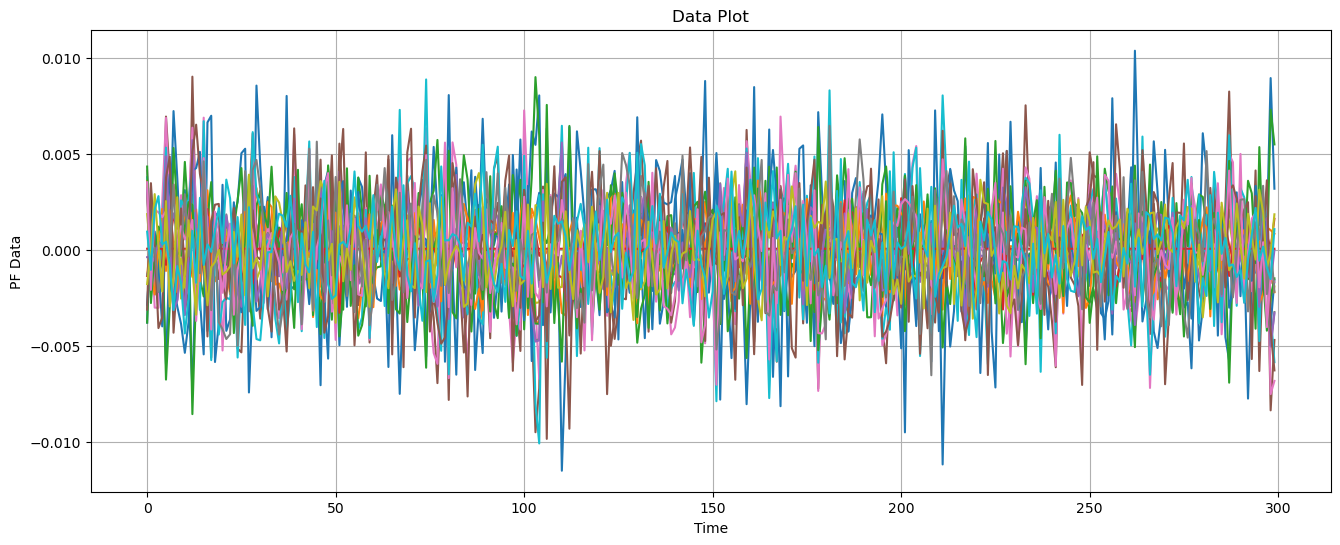

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm
import read_data
import networkx as nx
import plotGraph


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
# Load MATLAB file
file_name= 'matpower/test_data/DC_case14_.mat'
# Access a variable inside the .mat file
pfData, phaseData, H= read_data.read_mat_power(file_name, normalize= True)
A=np.array(H>0, dtype= np.float32)-np.array(H<0, dtype= np.float32)
print(H.shape)
data= pfData
print(data.shape)
plt.figure(figsize=(16, 6))
for i in range(data.shape[1]):
    #plt.plot(data.index, data[i], label=i)
    plt.plot(data[:, i], label=i)
plt.title('Data Plot')
plt.xlabel('Time')
plt.ylabel('PF Data')
# plt.legend()
plt.grid(True)
plt.show()

In [7]:
print(A)

[[ 1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0. -1

In [22]:
corMatrix= np.corrcoef(pfData.T)
print(np.round(corMatrix, 2))

[[ 1.    0.66  0.62  0.1  -0.11 -0.58 -0.32 -0.68 -0.72 -0.49 -0.29 -0.12
  -0.24  0.21 -0.71 -0.45 -0.3  -0.04 -0.04 -0.2 ]
 [ 0.66  1.    0.3   0.68  0.67 -0.06  0.14 -0.42 -0.43 -0.07 -0.42 -0.01
  -0.12  0.08 -0.41 -0.31 -0.06  0.24 -0.08 -0.32]
 [ 0.62  0.3   1.    0.17 -0.21 -0.94 -0.59 -0.75 -0.82 -0.6  -0.19 -0.24
  -0.33  0.39 -0.87 -0.43 -0.35 -0.08  0.02 -0.13]
 [ 0.1   0.68  0.17  1.    0.8   0.18 -0.11 -0.16 -0.19  0.01 -0.22 -0.13
  -0.2   0.13 -0.22 -0.17 -0.07  0.12 -0.01 -0.14]
 [-0.11  0.67 -0.21  0.8   1.    0.49  0.51  0.11  0.13  0.4  -0.28  0.1
   0.08 -0.11  0.16  0.04  0.22  0.36 -0.06 -0.22]
 [-0.58 -0.06 -0.94  0.18  0.49  1.    0.55  0.69  0.75  0.6   0.12  0.19
   0.26 -0.35  0.79  0.37  0.33  0.12 -0.02  0.08]
 [-0.32  0.14 -0.59 -0.11  0.51  0.55  1.    0.42  0.5   0.64 -0.15  0.35
   0.42 -0.37  0.57  0.31  0.47  0.42 -0.09 -0.18]
 [-0.68 -0.42 -0.75 -0.16  0.11  0.69  0.42  1.    0.98  0.56  0.33  0.
   0.08  0.06  0.85  0.33  0.05 -0.03  0.06  0.13]
 [-

In [3]:
UT, ST, VT= np.linalg.svd(H)
print(UT.shape)
print(1*(ST>1e-13).sum())
# print(ST)

(20, 20)
13


[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13]


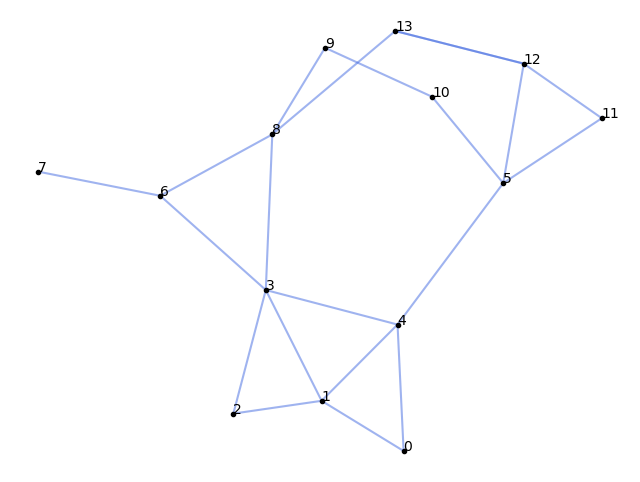

In [4]:
def from_A_to_G(A):
    # Create an empty directed graph
    G = nx.DiGraph()

    # Get the number of edges and nodes
    num_edges, num_nodes = A.shape

    # Add nodes to the graph
    G.add_nodes_from(range(num_nodes))

    # Add edges based on the topology matrix A
    for i in range(num_edges):
        source = np.where(A[i] == 1)[0]
        target = np.where(A[i] == -1)[0]
        if source.size > 0 and target.size > 0:
            G.add_edge(source[0], target[0])
    return G
G= from_A_to_G(A)
G= G.to_undirected()
biconnected_components = list(nx.biconnected_components(G))
largest_bcc = list(max(biconnected_components, key=len))
print(largest_bcc)
plotGraph.plot_spring_layout(G, label=True)

In [5]:
AM= A[:, largest_bcc].squeeze()
linkEntry= np.nonzero(1*(((abs(AM)>1e-1)*1).sum(axis=1)>1.5))
AM= AM[linkEntry, :].squeeze()
HM= H[linkEntry, :].squeeze()
HM= HM[:, largest_bcc].squeeze()
pfDataM= pfData[:, linkEntry].squeeze()
AM= AM[:, :]
print(A.shape)
print(AM.shape)

(20, 14)
(19, 13)


In [472]:
#P>0.1
# Define the model
class Net(nn.Module):
    def __init__(self, A):
        super(Net, self).__init__()
        self.P = torch.randn((A.shape[0], 1), dtype= torch.float64, device=device)*2 # Hidden layer
        self.P = torch.nn.Parameter(self.P)
        self.A = torch.tensor(A, dtype= torch.float64, device= device)
    def Hmat(self):
        return self.A*torch.abs(self.P)# aviod singular
    
    def InvHmat(self):
        H= self.Hmat()
        return torch.linalg.pinv(H)

    def encoder(self, x):
        Hinv= self.InvHmat()
        y1= Hinv.matmul(x.T)
        y1= y1#- y1[0:1, :]
        return y1
    def decoder(self, y1):
        H= self.Hmat()
        x = H.matmul(y1)
        return x.T
    def forward(self, x):
        y1= self.encoder(x)
        x_pre= self.decoder(y1)
        return x_pre
# Create the model and move it to the GPU
model = Net(AM).to(device, dtype=torch.float64)
losses= []

In [474]:


# Loss function and optimizer
criterion = nn.MSELoss()
# criterion= nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=1)
paras= []


In [513]:
import copy

# Convert data to PyTorch tensors
x_tensor = torch.tensor(pfDataM[0:290, :], dtype=torch.float64, device=device)


# Create a DataLoader
dataset = TensorDataset(x_tensor, x_tensor)
loader = DataLoader(dataset, batch_size=1024, shuffle=True)

# Training the model
epochs = 8000
bestLoss= 1e-9
bestModel= None
for epoch in tqdm(range(epochs)):
    for inputs, label in loader:
        optimizer.zero_grad()
        y1 = model.encoder(inputs)
        p_x = model.decoder(y1)
        MSELoss = criterion(p_x, inputs)
        loss= MSELoss
        if loss.item()<bestLoss:
            bestLoss= loss.item()
            bestModel= copy.deepcopy(model)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        paras.append(model.P.cpu().detach().numpy())

print("Training complete.")
print(loss)
print(MSELoss)

100%|██████████| 8000/8000 [05:22<00:00, 24.80it/s]

Training complete.
tensor(5.9632e-12, device='cuda:0', dtype=torch.float64,
       grad_fn=<MseLossBackward0>)
tensor(5.9632e-12, device='cuda:0', dtype=torch.float64,
       grad_fn=<MseLossBackward0>)


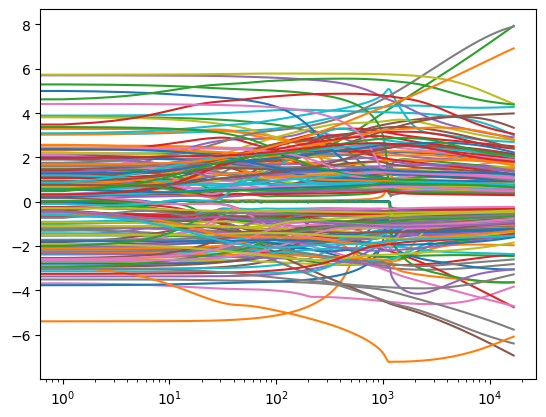

In [514]:
parasNp= np.stack(paras).squeeze()
plt.plot(parasNp[:, :])
plt.xscale("log")

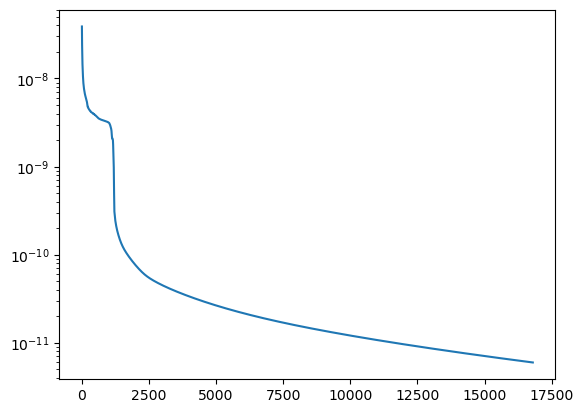

In [515]:
plt.plot(losses[:])
plt.yscale("log")
# plt.xscale("log")

In [516]:
portion=model.Hmat().cpu().detach().numpy()/(HM[:, :]+1e-18)
print(portion.sum(1, keepdims=True).T)
print(np.abs(HM).sum(1, keepdims=True).T/2)
print(np.abs(AM.dot(np.linalg.pinv(AM))).dot(np.ones((AM.shape[0], 1))).T)

[[0.09540646 0.09534658 0.07258543 0.09524253 0.09527544 0.09500529
  0.11547408 0.09370367 0.09470891 0.09605848 0.09545043 0.09544688
  0.09551219 0.10683242 0.10620229 0.10519461 0.10439537 0.10537124
  0.10693668 0.10457936 0.1070826  0.10699532 0.10966111 0.10711921
  0.10882842 0.10917482 0.10902098 0.112417   0.10670802 0.12601411
  0.10714244 0.1084915  0.10775075 0.10672138 0.10379792 0.10559974
  0.10955653 0.10676686 0.10803371 0.10874262 0.1050573  0.10890964
  0.10787105 0.05558056 0.05944064 0.10829178 0.05930628 0.06216856
  0.11185638 0.10970203 0.10971591 0.10866535 0.10977061 0.10999157
  0.10981331 0.10978837 0.10803264 0.11079754 0.10713396 0.10913976
  0.10918117 0.10930752 0.10977265 0.10966335 0.10966335 0.10912837
  0.10936328 0.10651248 0.10707604 0.10653123 0.10658138 0.1076507
  0.10730748 0.10730748 0.07976198 0.075951   0.08149093 0.10744725
  0.10678228 0.1075678  0.10624966 0.10689397 0.10684014 0.10684014
  0.10595691 0.10766569 0.10834167 0.09894719 0.1

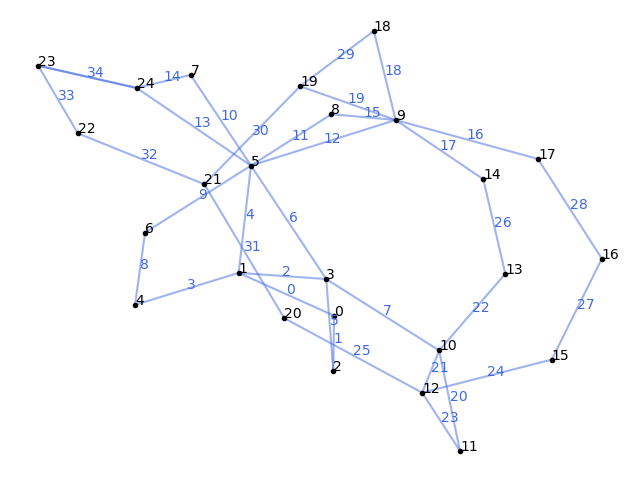

In [193]:
GM= from_A_to_G(AM)
GM= GM.to_undirected()# 4, 7, 10, 12
plotGraph.plot_spring_layout(GM, label=True, label_edge= True)

In [29]:
from scipy.linalg import null_space

nullT= null_space(H.T).T
nullP= null_space(bestModel.Hmat().cpu().detach().numpy())
preH= bestModel.Hmat().cpu().detach().numpy()


In [213]:
from scipy.io import savemat

savemat("PredH35_25.mat",{"HProtion": portion, "HPre": bestModel.Hmat().cpu().detach().numpy(), "loss": losses, "paras": parasNp})

Text(0, 0.5, 'Reconstruction Errors')

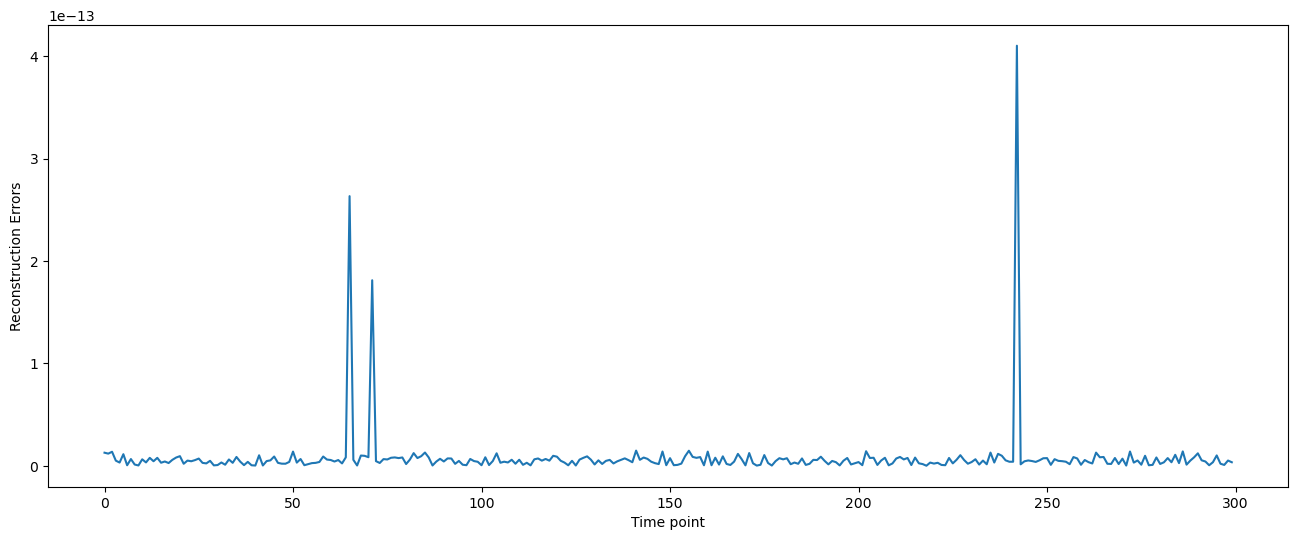

In [214]:
def apply_mean_filter_2d(data, window_size):
    # Define the filter kernel
    filter_kernel = np.ones(window_size) / window_size
    # Initialize the output array with the same shape as input
    filtered_data = np.zeros((data.shape[0]-window_size+1, data.shape[1]))
    # Apply the filter along each row
    for i in range(data.shape[1]):
        filtered_data[:, i] = np.convolve(data[:, i], filter_kernel, mode='valid')
    return filtered_data

x_test_tensor = torch.tensor(pfDataM, dtype=torch.float64, device=device)
y1= bestModel.encoder(x_test_tensor)
o_x= bestModel.decoder(y1)
bias= torch.square(x_test_tensor-o_x).detach().cpu().numpy()
bias= np.sqrt(bias.sum(axis=1))
plt.figure(figsize=(16, 6))
plt.plot(apply_mean_filter_2d(bias[:, None], 1))
plt.xlabel("Time point")
plt.ylabel("Reconstruction Errors")